0    1.25372
1    1.23378
2    1.20766
3    1.19457
4    1.17574
Name: SpotPriceDKK, dtype: float64
Loading demand profiles...
Demand profiles loaded!
Loading production data...
Production profiles loaded!
2.535
3.3217833333333333
Loading demand profiles...
Demand profiles loaded!
Loading production data...
Production profiles loaded!


/Users/antonlenander/anaconda3/envs/phantom/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-01-29 14:02:15,050	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-01-29 14:02:15,104	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-01-29 14:02:15,568	WARNING deprecation.py:50 -- DeprecationWarning: `DirectStepOptimizer` has been deprecated. This will raise an error in the future!


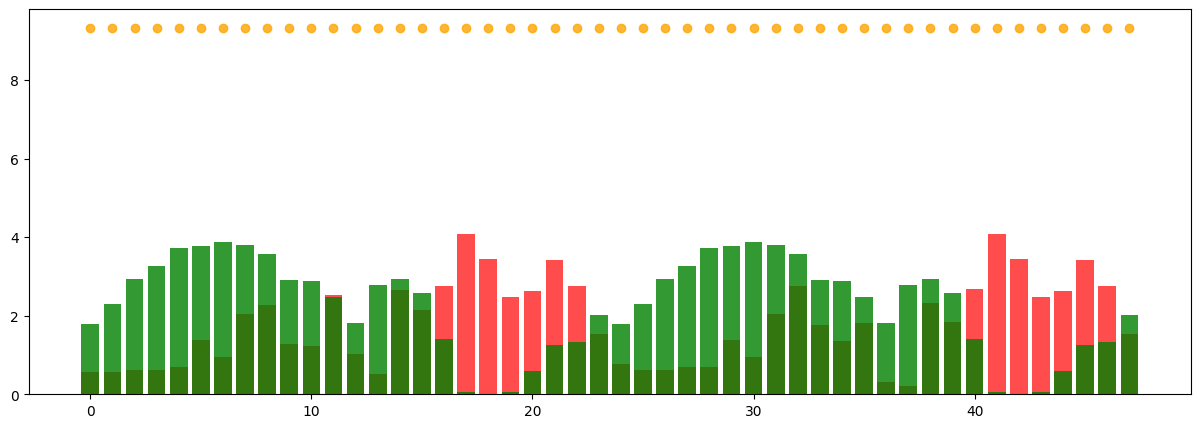

108.29959691692564
97.5687


In [1]:
import matplotlib.pyplot as plt
import cloudpickle
import numpy as np
from datamanager import DataManager

path = "output/flex_multi_combined/results.pkl"
outputfolder = "output/flex_multi_combined/"
start = 48*30*1 
end = 48*30*1 + 48*2
dm = DataManager(prod_path='data/eval/pv.csv', demand_path='data/eval/demandprofiles.csv', cap_path='data/eval/caps.csv')
max_price = dm.get_all_max_price() + 2.0666
max_price = max_price * 1.5

with open(path, "rb") as file:
    results = cloudpickle.load(file)

results = list(results)

for rollout in results:

    aid = "CM"
    agent_actions = []
    budget_balance = []
    capacity_balance = []
    cap_limits = []
    total_import = []
    prices = []
    total_load = []
    total_export = []
    total_export += list(rollout.metrics["cm/total_export"])
    total_load += list(rollout.metrics["env/total_load"])
    agent_actions += list(rollout.actions_for_agent(aid))
    budget_balance += list(rollout.metrics["cm/budget_balance"])
    capacity_balance += list(rollout.metrics["cm/capacity_balance"])
    cap_limits += list(rollout.metrics["cm/capacity_limit"])
    total_import += list(rollout.metrics["cm/total_import"])
    prices += list(rollout.metrics["env/current_price"])

    agent_actions = [action for action in agent_actions if action is not None]

    start = 48*2
    end = start + 48*2

    total_import = total_import[1:] + [0]
    total_export = total_export[1:] + [0]
    total_load = total_load[1:] + [0]
    total_export = total_export[start:end:2]
    total_load = total_load[start:end:2]
    agent_actions = agent_actions[start:end:2]
    capacity_balance = capacity_balance[start:end:2]
    cap_limits = cap_limits[start:end:2]
    total_import = total_import[start:end:2]
    prices = prices[start:end:2]
    #grid_prices

    #import_export = np.array(total_import) - np.array(total_export)
    

    # agent_actions = agent_actions[start:end]
    # capacity_balance = capacity_balance[start:end]
    # cap_limits = cap_limits[start:end]
    # total_import = total_import[start:end]
    # prices = prices[start:end]

    plt.figure(figsize=(15, 5))
    plt.bar(range(len(total_import)), total_import, color="red", alpha=0.7)
    
    plt.bar(range(len(cap_limits)), cap_limits, color="green", alpha=0.8, label="Capacity limit")
    #plt.bar(range(len(total_load)), total_load, color="blue", alpha=0.7)
    plt.scatter(range(len(prices)), prices, label="Price", color="orange", alpha=0.8)
    # plt.savefig(f"{outputfolder}import_limits.png")
    # plt.close()
    plt.show()

    print(np.sum(cap_limits))
    print(np.sum(total_load))

    #Plot distribution of agent action per step for all rollouts
    # plt.hist(agent_actions, bins=30, edgecolor='black')
    # prices = np.linspace(0.1, max_price, num=30)
    # print(prices)
    # plt.xticks(prices)
    # plt.title("Distribution of action values")
    # plt.xlabel("Agent action")
    # plt.ylabel("Frequency")
    # plt.savefig(f"action_dist_{aid}.png")
    # plt.close()


In [2]:
results = list(results)
for rollout in results:
    for i in range(1,6):
        aid = f"H{i}"
        agent_actions = []
        agent_demand = []
        agent_charge = []
        agent_supply = []
        agent_prod = []
        prices = []
        agent_actions += list(rollout.actions_for_agent(aid))
        agent_demand += list(rollout.metrics[f"{aid}/current_load"])
        agent_charge += list(rollout.metrics[f"{aid}/current_charge"])
        agent_supply += list(rollout.metrics[f"{aid}/current_supply"])
        agent_prod += list(rollout.metrics[f"{aid}/current_prod"])
        prices += list(rollout.metrics["env/current_price"])

        for idx, action in enumerate(agent_actions):
            if action is None:
                agent_actions[idx] = agent_actions[idx + 1] if idx + 1 < len(agent_actions) else 6

        start = 48*30*1 
        end = 48*30*1 + 48*2

        agent_actions = agent_actions[start:end:2]
        agent_demand = agent_demand[start:end:2]
        agent_charge = agent_charge[start:end:2]
        agent_supply = agent_supply[start:end:2]
        agent_prod = agent_prod[start:end:2]
        prices = prices[start:end:2]
    

        fig, ax1 = plt.subplots()

        ax2 = ax1.twinx()
        ax2.scatter(range(len(agent_actions)), agent_actions, label="Action", color='tab:green', alpha=0.5)
        ax2.set_ylabel('Action')
        ax2.set_yticks([0, 1, 2, 3, 4, 5])
        ax2.set_yticklabels(['buy', 'buycharge', 'sell', 'sellcharge', 'charge', 'noop'])
        ax2.legend(loc='upper right')
        
        #ax1.bar(range(len(agent_demand)), agent_demand, label="Demand", color='tab:blue', alpha=1)
        ax1.bar(range(len(agent_charge)), agent_charge, label="Charge", color='tab:orange', alpha=0.5)
        ax1.bar(range(len(agent_supply)), agent_supply, label="Supply", color='tab:red', alpha=0.6)
        #ax1.bar(range(len(agent_prod)), agent_prod, label="Production", color='tab:purple', alpha=0.6)
        ax1.scatter(range(len(prices)), prices, label="Price", color='tab:grey', alpha=0.8)
        ax1.set_xlabel('Time step')
        ax1.set_ylabel('Demand/Charge')
        ax1.legend(loc='upper left')


        fig.tight_layout()
        plt.savefig(f"{outputfolder}demand_charge_action_{aid}.png")
        plt.close()